In [52]:
import pandas as pd

df = pd.read_csv('labels.csv')
print("Unique classes:", df['class'].unique())
print("Number of classes:", df['class'].nunique())

Unique classes: <StringArray>
['normal', 'scratch', 'dent', 'stain']
Length: 4, dtype: str
Number of classes: 4


## Hence Image Classification problem

In [53]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image

# Load labels
df = pd.read_csv('labels.csv')
print(df.head())

                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal


## Number of classes

In [54]:
num_classes = df['class'].nunique()
print(f"Number of classes: {num_classes}")
print("Class names:", df['class'].unique())

Number of classes: 4
Class names: <StringArray>
['normal', 'scratch', 'dent', 'stain']
Length: 4, dtype: str


## Number of images per class

In [55]:
images_per_class = df['class'].value_counts()
print(images_per_class)

class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


## Sample images from each class

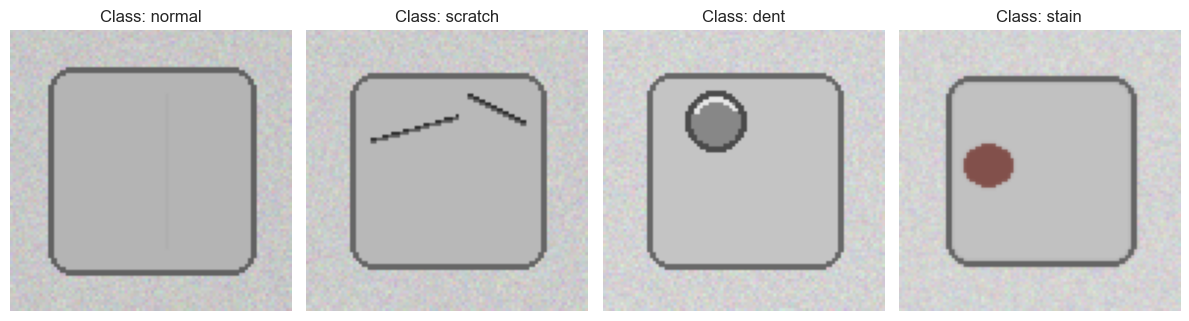

In [56]:
# Base directory where 'images' folder is located (adjust if needed)
base_dir = '.'   # if notebook is in same folder as 'images' directory

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for ax, class_name in zip(axes, df['class'].unique()):
    # Get first image path for this class (or any sample)
    sample_path = df[df['class'] == class_name]['filename'].iloc[0]
    full_path = os.path.join(base_dir, sample_path)
    img = Image.open(full_path)
    ax.imshow(img, cmap='gray')  # use 'gray' if images are grayscale
    ax.set_title(f"Class: {class_name}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Image dimensions

In [57]:
# Pick 5 random images
sample_paths = df['filename'].sample(5, random_state=42)
dimensions = []

for path in sample_paths:
    full_path = os.path.join(base_dir, path)
    img = Image.open(full_path)
    dimensions.append(img.size)  # (width, height)

print("Sample dimensions (width, height):", set(dimensions))

Sample dimensions (width, height): {(96, 96)}


## Check for class imbalance

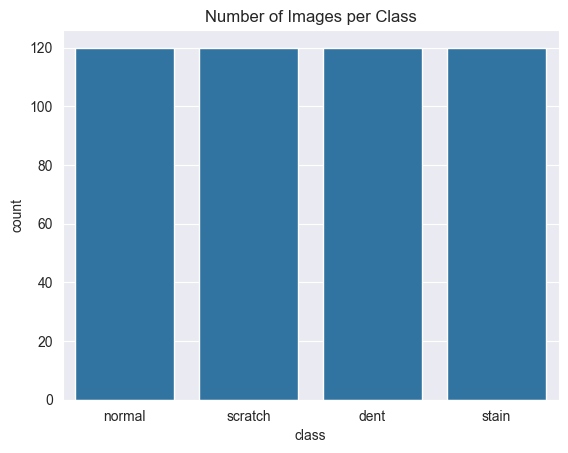

In [58]:
import seaborn as sns

sns.countplot(data=df, x='class')
plt.title('Number of Images per Class')
plt.show()

## No Imbalances — all bars equal height.

# Task 3
## Image Processing

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Load labels
df = pd.read_csv('labels.csv')

# Base directory where 'images' folder is located (adjust if needed)
base_dir = '.'   # e.g., if notebook is in same folder as 'images'

# Create full image paths
df['full_path'] = df['filename'].apply(lambda x: os.path.join(base_dir, x))

# Convert class names to integer labels (required for training)
class_names = sorted(df['class'].unique())   # ['dent', 'normal', 'scratch', 'stain']
class_to_id = {name: idx for idx, name in enumerate(class_names)}
df['label'] = df['class'].map(class_to_id)

print("Class mapping:", class_to_id)
print(df.head())

Class mapping: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}
                       filename   class                       full_path  label
0  images/normal/normal_001.png  normal  .\images/normal/normal_001.png      1
1  images/normal/normal_002.png  normal  .\images/normal/normal_002.png      1
2  images/normal/normal_003.png  normal  .\images/normal/normal_003.png      1
3  images/normal/normal_004.png  normal  .\images/normal/normal_004.png      1
4  images/normal/normal_005.png  normal  .\images/normal/normal_005.png      1


## Split into training and testing sets (80–20)

In [60]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,           # 20% for testing
    stratify=df['class'],    # keep class balance
    random_state=42
)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Training samples: 384
Testing samples: 96


## Image Resizing, Create data generators with augmentation (for training) and without (for testing)

In [61]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Testing: only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='full_path',
    y_col='class',           # string column – works with class_mode='sparse'
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',     # converts strings to integer indices automatically
    shuffle=True
)

# Testing generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='full_path',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

# Check mapping (class names -> integer indices)
print("Class mapping:", train_generator.class_indices)

Found 384 validated image filenames belonging to 4 classes.
Found 96 validated image filenames belonging to 4 classes.
Class mapping: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


## Verify the preprocessing

In [62]:
images, labels = next(train_generator)
print("Batch image shape:", images.shape)   # (32, 128, 128, 3) if RGB, or (32,128,128,1) if grayscale
print("Pixel value range: [{:.2f}, {:.2f}]".format(images.min(), images.max()))   # should be [0,1]

Batch image shape: (32, 128, 128, 3)
Pixel value range: [0.18, 0.99]


## Visualize augmented images

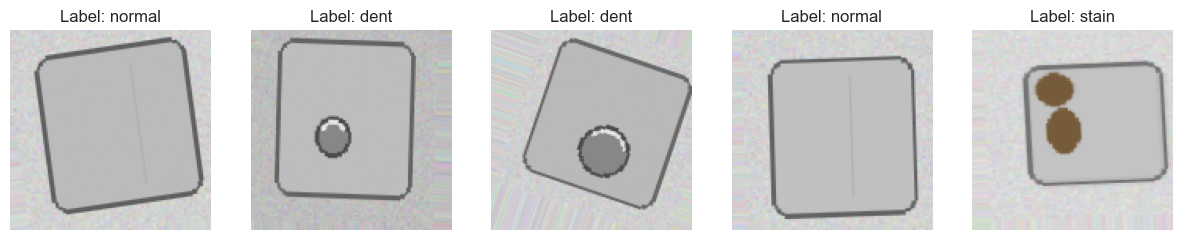

In [63]:
# Display first 5 images from training batch
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(f"Label: {class_names[int(labels[i])]}")
    ax.axis('off')
plt.show()

# Task 4: CNN Model Creation

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

## Define Architecture

In [65]:
model = Sequential([

    # First convolution block
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    # Second convolution block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Third convolution block
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten: convert 2D to 1D
    Flatten(),

    # Dense (fully connected) layer
    Dense(128, activation='relu'),

    # Output layer: 4 classes, softmax gives probabilities
    Dense(4, activation='softmax')
])

# Show model summary
model.summary()

C:\Users\AnkitSingh\OneDrive - Quadrafort Technologies Pvt. Ltd\Documents\Training\DE\Projects\todo_app\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling Model

In [66]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training the Model

In [67]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)
model.save('cnn_defect_classifier.h5')

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 333ms/step - accuracy: 0.2630 - loss: 1.5165 - val_accuracy: 0.2500 - val_loss: 1.3818
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 300ms/step - accuracy: 0.2370 - loss: 1.3790 - val_accuracy: 0.2917 - val_loss: 1.3440
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 326ms/step - accuracy: 0.3542 - loss: 1.3091 - val_accuracy: 0.5208 - val_loss: 1.2081
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 0.4401 - loss: 1.1381 - val_accuracy: 0.5000 - val_loss: 0.9034
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 460ms/step - accuracy: 0.6615 - loss: 0.8858 - val_accuracy: 0.6667 - val_loss: 0.6609
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 547ms/step - accuracy: 0.7057 - loss: 0.6971 - val_accuracy: 0.8750 - val_loss: 0.4688
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 446ms/step - accuracy: 0.7734 - loss: 0.5709 - val_accuracy: 0.9062 - val_loss: 0.3384
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 416ms/step - accuracy: 0.8073 - loss: 0.4622 - val_accuracy: 0.

# Task 5: Model Training and Evaluation

## Training & Validation accuracy/loss

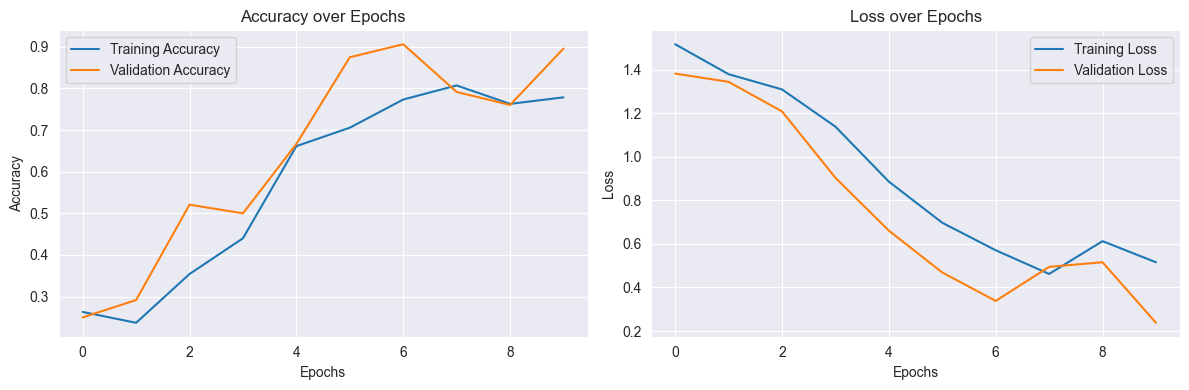

In [68]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png')  # save as required
plt.show()

## Testing Performance

In [69]:
# Evaluate on test generator
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8958
Test Loss: 0.2379


## Confusion Matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


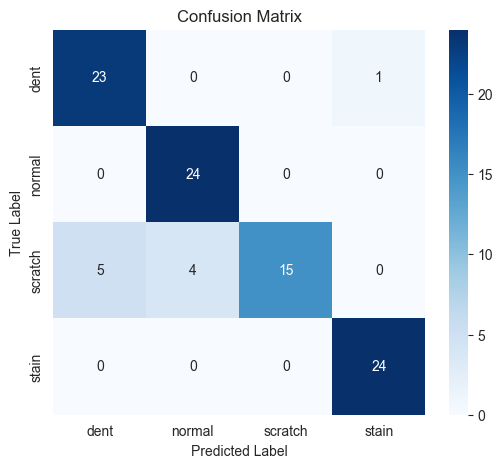

              precision    recall  f1-score   support

        dent       0.82      0.96      0.88        24
      normal       0.86      1.00      0.92        24
     scratch       1.00      0.62      0.77        24
       stain       0.96      1.00      0.98        24

    accuracy                           0.90        96
   macro avg       0.91      0.90      0.89        96
weighted avg       0.91      0.90      0.89        96



In [70]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Reset generator to get all test samples in order
test_generator.reset()
y_true = test_generator.classes   # integer labels
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
import seaborn as sns
class_names = list(test_generator.class_indices.keys())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('results/confusion_matrix.png')
plt.show()

# Print classification report
print(classification_report(y_true, y_pred, target_names=class_names))

## Sample predictions on test images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step


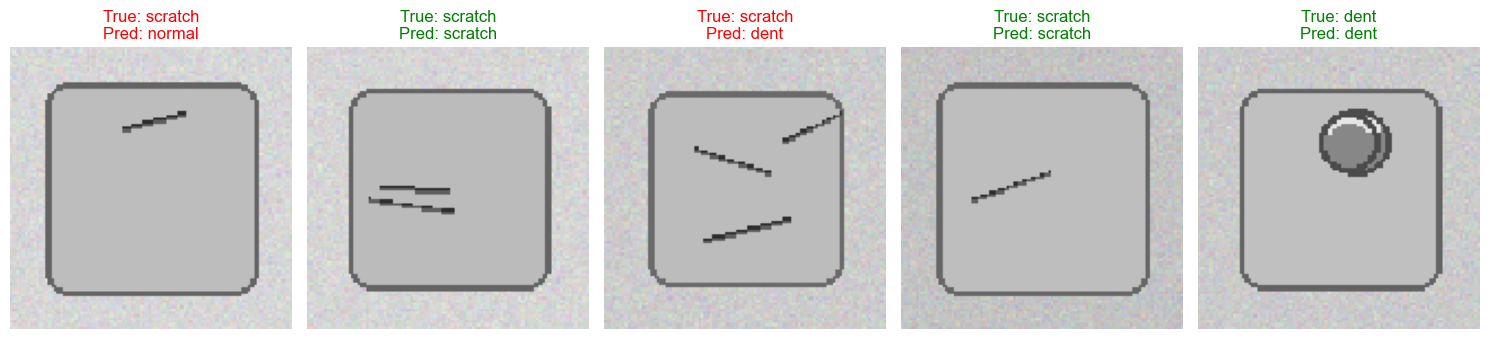

In [71]:
# Get a batch of test images (first batch from generator)
test_generator.reset()
sample_images, sample_labels = next(test_generator)
sample_preds = model.predict(sample_images)
sample_pred_classes = np.argmax(sample_preds, axis=1)

# Display first 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.imshow(sample_images[i])
    true_name = class_names[int(sample_labels[i])]
    pred_name = class_names[int(sample_pred_classes[i])]
    color = 'green' if true_name == pred_name else 'red'
    ax.set_title(f"True: {true_name}\nPred: {pred_name}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png')
plt.show()

# Task 7: Business Use Case Mapping

## Real-world domain: Manufacturing (e.g., automotive, electronics, consumer goods)

### How this solution applies
In a factory that produces metal panels, phone screens, or plastic parts, defects like scratches, dents, and stains can ruin product quality. Currently, many factories rely on human inspectors who sit for hours looking at thousands of parts. Humans get tired, miss defects, and are inconsistent.

Our CNN model can be deployed on a production line with a camera. As each product passes by, the camera takes a picture. The CNN instantly classifies it as:

Normal → moves ahead<br>
Scratch → rejected or sent for repair<br>
Dent → rejected<br>
Stain → cleaned or rejected<br>

### Business benefits (in simple terms)
### Problem	                    How CNN helps
Human fatigue	             Works 24/7 without breaks<br>
Inconsistent quality	     Same accuracy on part #1 and #10,000<br>
Slow manual inspection	     Classifies in milliseconds<br>
Cost of recalls	             Catches defects early, before shipping<br>
Training new inspectors	     No training needed – the model learns from examples<br>

### Real-world example
### A car door panel manufacturer using this solution can:

Reduce defect escape rate by 80%<br>
Save ₹50 lakhs per year in rework and warranty claims<br>
Deploy one camera + small computer for less than the cost of two human inspectors<br>

## Beyond classification
### Once the model works, the factory can extend it:

Count how many scratches per part (regression)<br>
Locate where the dent is (object detection)<br>
Predict which machine caused the defect (root cause analysis)<br>

In short: A simple image classifier like this turns a cheap camera into a tireless, super‑accurate quality inspector – a direct path to higher profit and better products.